# 🔧 LoanGuard — Veri Ön-İşleme (Preprocessing)

**Amaç:** EDA'da elde edilen bulgular doğrultusunda ham veriyi modellemeye hazır hale getirmek.

**EDA'dan Gelen Bulgular:**
- ✅ Eksik değer yok → Imputation gerekmez
- ✅ Tekrar eden satır yok
- ⚠️ Bazı sayısal sütunlarda aykırı değerler mevcut → IQR ile kırpılacak
- ⚠️ Sınıf dengesizliği (~7.6:1) → `scale_pos_weight` modelde uygulanacak

**Bu Notebook'ta Yapılacaklar:**
1. YAML konfigürasyonunu yükle
2. ID sütununu kaldır
3. Aykırı değerleri IQR ile kırp (clip)
4. Kategorik değişkenleri encode et (LabelEncoder)
5. Feature / Target ayrımı yap
6. Train / Test split (%80/%20, stratified)
7. Sayısal değişkenleri ölçeklendir (StandardScaler)
8. İşlenmiş veriyi `data/processed/` klasörüne kaydet

---

## 1. Kütüphaneler & Konfigürasyon

Proje konfigürasyonu `configs/model_params.yaml` dosyasından okunur.  
Bu sayede parametreler tek bir merkezden yönetilir; notebook'a sabit değer (hardcode) yazılmaz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import joblib
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# YAML konfigürasyon dosyasını yükle
# ---------------------------------------------------------------------------
with open("../configs/model_params.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Konfigürasyondan parametreleri al
TEST_SIZE       = config["data"]["test_size"]           # 0.2
RANDOM_STATE    = config["data"]["random_state"]        # 42
STRATIFY_COL    = config["data"]["stratify_column"]     # "Default"
SCALER_TYPE     = config["preprocessing"]["numeric_scaler"]       # "StandardScaler"
ENCODER_TYPE    = config["preprocessing"]["categorical_encoder"]  # "LabelEncoder"
HANDLE_OUTLIERS = config["preprocessing"]["handle_outliers"]      # True
OUTLIER_METHOD  = config["preprocessing"]["outlier_method"]       # "IQR"
OUTLIER_THRESH  = config["preprocessing"]["outlier_threshold"]    # 1.5

print("✅ Konfigürasyon yüklendi:")
print(f"   Test oranı      : {TEST_SIZE}")
print(f"   Random state    : {RANDOM_STATE}")
print(f"   Scaler          : {SCALER_TYPE}")
print(f"   Encoder         : {ENCODER_TYPE}")
print(f"   Outlier yöntemi : {OUTLIER_METHOD} (threshold={OUTLIER_THRESH})")

✅ Konfigürasyon yüklendi:
   Test oranı      : 0.2
   Random state    : 42
   Scaler          : StandardScaler
   Encoder         : LabelEncoder
   Outlier yöntemi : IQR (threshold=1.5)


In [2]:
# ---------------------------------------------------------------------------
# Sütun gruplarını tanımla (EDA'dan aynı tanım)
# ---------------------------------------------------------------------------
NUMERICAL_COLS = [
    "Age", "Income", "LoanAmount", "CreditScore",
    "MonthsEmployed", "NumCreditLines", "InterestRate",
    "LoanTerm", "DTIRatio"
]

CATEGORICAL_COLS = [
    "Education", "EmploymentType", "MaritalStatus",
    "HasMortgage", "HasDependents", "LoanPurpose", "HasCoSigner"
]

TARGET_COL = "Default"
ID_COL = "LoanID"

# Çıktı klasörleri
PROCESSED_DIR = "../data/processed/"
MODELS_DIR = "../models/"
FIGURES_DIR = "../reports/figures/"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Görselleştirme ayarları
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

print("✅ Sabitler ve çıktı klasörleri hazır.")

✅ Sabitler ve çıktı klasörleri hazır.


---
## 2. Veri Yükleme & ID Sütununu Kaldırma

`LoanID` sütunu sadece bir kimlik numarasıdır; model için bilgi taşımaz.  
Modele verilirse hem gereksiz gürültü oluşturur hem de boyut artar.

In [3]:
# ---------------------------------------------------------------------------
# Ham veriyi yükle
# ---------------------------------------------------------------------------
df = pd.read_csv("../data/raw/Loan_default.csv")
print(f"📐 Ham veri boyutu: {df.shape[0]:,} satır × {df.shape[1]} sütun")

# ---------------------------------------------------------------------------
# ID sütununu düşür — model için anlamsız
# ---------------------------------------------------------------------------
df = df.drop(columns=[ID_COL])
print(f"🗑️  '{ID_COL}' sütunu kaldırıldı → Yeni boyut: {df.shape[0]:,} × {df.shape[1]}")
df.head()

📐 Ham veri boyutu: 255,347 satır × 18 sütun
🗑️  'LoanID' sütunu kaldırıldı → Yeni boyut: 255,347 × 17


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


---
## 3. Aykırı Değerleri Kırpma (IQR Clipping)

EDA'da bazı sayısal sütunlarda IQR sınırlarının dışında kalan aykırı değerler tespit ettik.  
Bu değerleri **silmek yerine kırpıyoruz (clipping)** — yani alt ve üst sınıra çekiyoruz.

**Neden silmiyoruz?**
- Silmek veri kaybına neden olur (255K'dan veri düşer)
- Kırpmak bilgiyi korur, sadece uç noktaları yumuşatır
- Sektörde en yaygın yöntem budur

**Formül:**
- Alt sınır = Q1 − 1.5 × IQR
- Üst sınır = Q3 + 1.5 × IQR
- Değer < Alt sınır → Alt sınıra çek
- Değer > Üst sınır → Üst sınıra çek

In [4]:
# ---------------------------------------------------------------------------
# IQR tabanlı kırpma (clipping) fonksiyonu
# ---------------------------------------------------------------------------
def clip_outliers_iqr(dataframe, columns, threshold=1.5):
    """
    IQR yöntemiyle aykırı değerleri kırpar.
    Silmek yerine alt/üst sınıra çeker (winsorize).
    
    Returns:
        dataframe: Kırpılmış DataFrame
        report: Her sütun için kaç değerin kırpıldığı
    """
    df_clipped = dataframe.copy()
    report = []
    
    for col in columns:
        q1 = df_clipped[col].quantile(0.25)
        q3 = df_clipped[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - threshold * iqr
        upper = q3 + threshold * iqr
        
        # Kırpılacak değer sayısı
        clipped_low = (df_clipped[col] < lower).sum()
        clipped_high = (df_clipped[col] > upper).sum()
        total_clipped = clipped_low + clipped_high
        
        # Kırpma işlemi
        df_clipped[col] = df_clipped[col].clip(lower=lower, upper=upper)
        
        report.append({
            "Sütun": col,
            "Alt Sınır": round(lower, 2),
            "Üst Sınır": round(upper, 2),
            "Kırpılan (Alt)": clipped_low,
            "Kırpılan (Üst)": clipped_high,
            "Toplam Kırpılan": total_clipped,
            "Oran (%)": round(total_clipped / len(dataframe) * 100, 2)
        })
    
    return df_clipped, pd.DataFrame(report)


# Kırpma işlemini uygula
if HANDLE_OUTLIERS:
    original_stats = df[NUMERICAL_COLS].describe()
    df, clip_report = clip_outliers_iqr(df, NUMERICAL_COLS, threshold=OUTLIER_THRESH)
    print(f"✅ Aykırı değer kırpma tamamlandı (yöntem: {OUTLIER_METHOD}, threshold: {OUTLIER_THRESH})")
    print()
    clip_report.set_index("Sütun")
else:
    print("⏭️  Aykırı değer işleme devre dışı (config: handle_outliers=false)")

⏭️  Aykırı değer işleme devre dışı (config: handle_outliers=false)


In [5]:
# ---------------------------------------------------------------------------
# Kırpma öncesi vs sonrası karşılaştırma (Boxplot)
# ---------------------------------------------------------------------------
if HANDLE_OUTLIERS:
    # Kırpma öncesi verileri yeniden yükle (karşılaştırma için)
    df_raw = pd.read_csv("../data/raw/Loan_default.csv")
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    axes = axes.flatten()
    
    for i, col in enumerate(NUMERICAL_COLS):
        ax = axes[i]
        
        # Önceki ve sonraki verileri yan yana çiz
        data_to_plot = pd.DataFrame({
            "Önce": df_raw[col],
            "Sonra": df[col]
        })
        
        bp = ax.boxplot(
            [data_to_plot["Önce"], data_to_plot["Sonra"]],
            labels=["Önce", "Sonra"],
            patch_artist=True,
            widths=0.4,
            flierprops=dict(marker="o", markersize=2, alpha=0.3)
        )
        
        # Renklendirme
        bp["boxes"][0].set_facecolor("#e74c3c")  # Öncesi — kırmızı
        bp["boxes"][0].set_alpha(0.6)
        bp["boxes"][1].set_facecolor("#27ae60")  # Sonrası — yeşil
        bp["boxes"][1].set_alpha(0.6)
        
        ax.set_title(col, fontsize=12, fontweight="bold")
    
    fig.suptitle(
        "Aykırı Değer Kırpma — Önce vs Sonra (IQR × 1.5)   🔴 Önce   🟢 Sonra",
        fontsize=15, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}09_outlier_clipping_comparison.png", bbox_inches="tight")
    plt.show()
    
    del df_raw  # Belleği serbest bırak

---
## 4. Kategorik Değişkenleri Encode Etme

ML modelleri sayısal verilerle çalışır; metin (string) değerleri anlayamaz.  
Bu yüzden kategorik sütunları sayıya dönüştürmemiz gerekir.

**LabelEncoder seçildi çünkü:**
- XGBoost, ağaç tabanlı bir modeldir ve kategorik sıralamayı kendisi öğrenebilir
- One-Hot Encoding sütun sayısını şişirirdi (7 kategorik → 20+ sütun)
- LabelEncoder her kategoriyi basitçe bir sayıya dönüştürür (A→0, B→1, C→2)

**Önemli:** Her sütun için ayrı bir LabelEncoder nesnesi oluşturulur ve kaydedilir.  
Böylece API'de yeni veri geldiğinde aynı dönüşüm uygulanabilir.

In [6]:
# ---------------------------------------------------------------------------
# Kategorik sütunları LabelEncoder ile sayısala çevir
# ---------------------------------------------------------------------------
label_encoders = {}  # Her sütunun encoder'ını sakla (inference için)

print("🔄 Kategorik sütunlar encode ediliyor...\n")
print(f"{'Sütun':<18} {'Benzersiz Değerler':<40} {'Eşleşme (Mapping)'}")
print("-" * 90)

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    
    # Eşleşme tablosunu göster
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col:<18} {str(le.classes_):<40} {mapping}")

print(f"\n✅ {len(CATEGORICAL_COLS)} kategorik sütun encode edildi.")
print(f"💾 Encoder'lar kaydedilecek (inference için).")

🔄 Kategorik sütunlar encode ediliyor...

Sütun              Benzersiz Değerler                       Eşleşme (Mapping)
------------------------------------------------------------------------------------------
Education          ["Bachelor's" 'High School' "Master's" 'PhD'] {"Bachelor's": 0, 'High School': 1, "Master's": 2, 'PhD': 3}
EmploymentType     ['Full-time' 'Part-time' 'Self-employed' 'Unemployed'] {'Full-time': 0, 'Part-time': 1, 'Self-employed': 2, 'Unemployed': 3}
MaritalStatus      ['Divorced' 'Married' 'Single']          {'Divorced': 0, 'Married': 1, 'Single': 2}
HasMortgage        ['No' 'Yes']                             {'No': 0, 'Yes': 1}
HasDependents      ['No' 'Yes']                             {'No': 0, 'Yes': 1}
LoanPurpose        ['Auto' 'Business' 'Education' 'Home' 'Other'] {'Auto': 0, 'Business': 1, 'Education': 2, 'Home': 3, 'Other': 4}
HasCoSigner        ['No' 'Yes']                             {'No': 0, 'Yes': 1}

✅ 7 kategorik sütun encode edildi.
💾 Encoder

In [7]:
# ---------------------------------------------------------------------------
# Encode sonrası veri tiplerini kontrol et — hepsi sayısal olmalı
# ---------------------------------------------------------------------------
print("📋 Encode sonrası veri tipleri:\n")
print(df.dtypes.to_string())
print(f"\n✅ Tüm sütunlar sayısal: {df.select_dtypes(include='object').shape[1] == 0}")

📋 Encode sonrası veri tipleri:

Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education           int32
EmploymentType      int32
MaritalStatus       int32
HasMortgage         int32
HasDependents       int32
LoanPurpose         int32
HasCoSigner         int32
Default             int64

✅ Tüm sütunlar sayısal: True


---
## 5. Feature / Target Ayrımı

Modele giriş olacak bağımsız değişkenler (**X**) ile tahmin edeceğimiz hedef değişken (**y**) ayrılır.

- **X** = Tüm sütunlar − Target sütunu
- **y** = Sadece `Default` sütunu

In [8]:
# ---------------------------------------------------------------------------
# Feature (X) ve Target (y) ayrımı
# ---------------------------------------------------------------------------
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print(f"📊 Feature matrisi (X): {X.shape[0]:,} satır × {X.shape[1]} özellik")
print(f"🎯 Hedef vektörü  (y): {y.shape[0]:,} eleman")
print(f"\n📌 Feature sütunları: {list(X.columns)}")
print(f"\n⚖️  Sınıf dağılımı:")
print(f"   Ödedi (0)   : {(y == 0).sum():,} (%{(y == 0).mean() * 100:.1f})")
print(f"   Temerrüt (1): {(y == 1).sum():,} (%{(y == 1).mean() * 100:.1f})")

📊 Feature matrisi (X): 255,347 satır × 16 özellik
🎯 Hedef vektörü  (y): 255,347 eleman

📌 Feature sütunları: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

⚖️  Sınıf dağılımı:
   Ödedi (0)   : 225,694 (%88.4)
   Temerrüt (1): 29,653 (%11.6)


---
## 6. Train / Test Split (Stratified)

Veriyi eğitim (%80) ve test (%20) olarak ikiye bölüyoruz.

**Stratified split** kullanıyoruz çünkü:
- Sınıf dengesizliği var (~%88 vs ~%12)
- Normal split'te test setine çok az temerrüt düşebilir
- Stratified split, oranları her iki sette de korur

```
Stratified Split:
  Train → %88 ödedi, %12 temerrüt   ← Oranlar korunuyor ✅
  Test  → %88 ödedi, %12 temerrüt   ← Oranlar korunuyor ✅

Normal Split (riskli):
  Train → %90 ödedi, %10 temerrüt   ← Oran kaydı ❌
  Test  → %83 ödedi, %17 temerrüt   ← Oran kaydı ❌
```

In [9]:
# ---------------------------------------------------------------------------
# Stratified Train / Test Split
# ---------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y  # Sınıf oranlarını koru
)

print(f"✅ Veri bölme tamamlandı (test_size={TEST_SIZE}, stratified)")
print(f"\n{'Set':<8} {'Satır':>10} {'Ödedi (0)':>12} {'Temerrüt (1)':>14} {'Temerrüt (%)':>14}")
print("-" * 60)

for name, X_set, y_set in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
    n_0 = (y_set == 0).sum()
    n_1 = (y_set == 1).sum()
    pct_1 = y_set.mean() * 100
    print(f"{name:<8} {len(y_set):>10,} {n_0:>12,} {n_1:>14,} {pct_1:>13.1f}%")

print(f"\n📌 Feature sayısı: {X_train.shape[1]}")

✅ Veri bölme tamamlandı (test_size=0.2, stratified)

Set           Satır    Ödedi (0)   Temerrüt (1)   Temerrüt (%)
------------------------------------------------------------
Train       204,277      180,555         23,722          11.6%
Test         51,070       45,139          5,931          11.6%

📌 Feature sayısı: 16


---
## 7. Sayısal Değişkenleri Ölçeklendirme (Scaling)

**StandardScaler** kullanarak sayısal değişkenleri standartlaştırıyoruz: μ=0, σ=1.

**Neden ölçekleme yapılır?**
- `Income` 15.000–200.000 arasında, `DTIRatio` 0–1 arasında olabilir
- Farklı ölçekler modeli yanıltabilir (özellikle Logistic Regression, SVM için)
- XGBoost ölçeklemeye duyarsızdır ama pipeline tutarlılığı için yine de yapılır

**⚠️ Kritik Kural: Data Leakage'dan Kaçınma**
- Scaler **sadece eğitim verisine** fit edilir
- Test verisine sadece **transform** uygulanır
- Bu kuralı ihlal etmek = test verisinden bilgi sızdırmak = sonuçlar güvenilmez olur

```
✅ Doğru:  scaler.fit(X_train)  →  scaler.transform(X_test)
❌ Yanlış: scaler.fit(X_tümü)   →  sonra train/test böl
❌ Yanlış: scaler.fit(X_test)   →  test'ten bilgi sızar
```

In [10]:
# ---------------------------------------------------------------------------
# StandardScaler — Sadece train üzerinde fit, test'e sadece transform
# ---------------------------------------------------------------------------
scaler = StandardScaler()

# Fit SADECE train verisine
X_train[NUMERICAL_COLS] = scaler.fit_transform(X_train[NUMERICAL_COLS])

# Transform test verisine (fit yok!)
X_test[NUMERICAL_COLS] = scaler.transform(X_test[NUMERICAL_COLS])

print("✅ Sayısal sütunlar ölçeklendirildi (StandardScaler)")
print("   → Scaler sadece eğitim verisine fit edildi (data leakage yok)")
print(f"\n📊 Ölçekleme sonrası train istatistikleri:")
X_train[NUMERICAL_COLS].describe().round(3).T[["mean", "std", "min", "max"]]

✅ Sayısal sütunlar ölçeklendirildi (StandardScaler)
   → Scaler sadece eğitim verisine fit edildi (data leakage yok)

📊 Ölçekleme sonrası train istatistikleri:


,mean,std,min,max
Age,-0.0,1.0,-1.702,1.701
Income,0.0,1.0,-1.733,1.731
LoanAmount,-0.0,1.0,-1.729,1.728
CreditScore,0.0,1.0,-1.727,1.728
MonthsEmployed,-0.0,1.0,-1.719,1.714
NumCreditLines,0.0,1.0,-1.345,1.341
InterestRate,0.0,1.0,-1.731,1.734
LoanTerm,0.0,1.0,-1.413,1.414
DTIRatio,0.0,1.0,-1.734,1.729


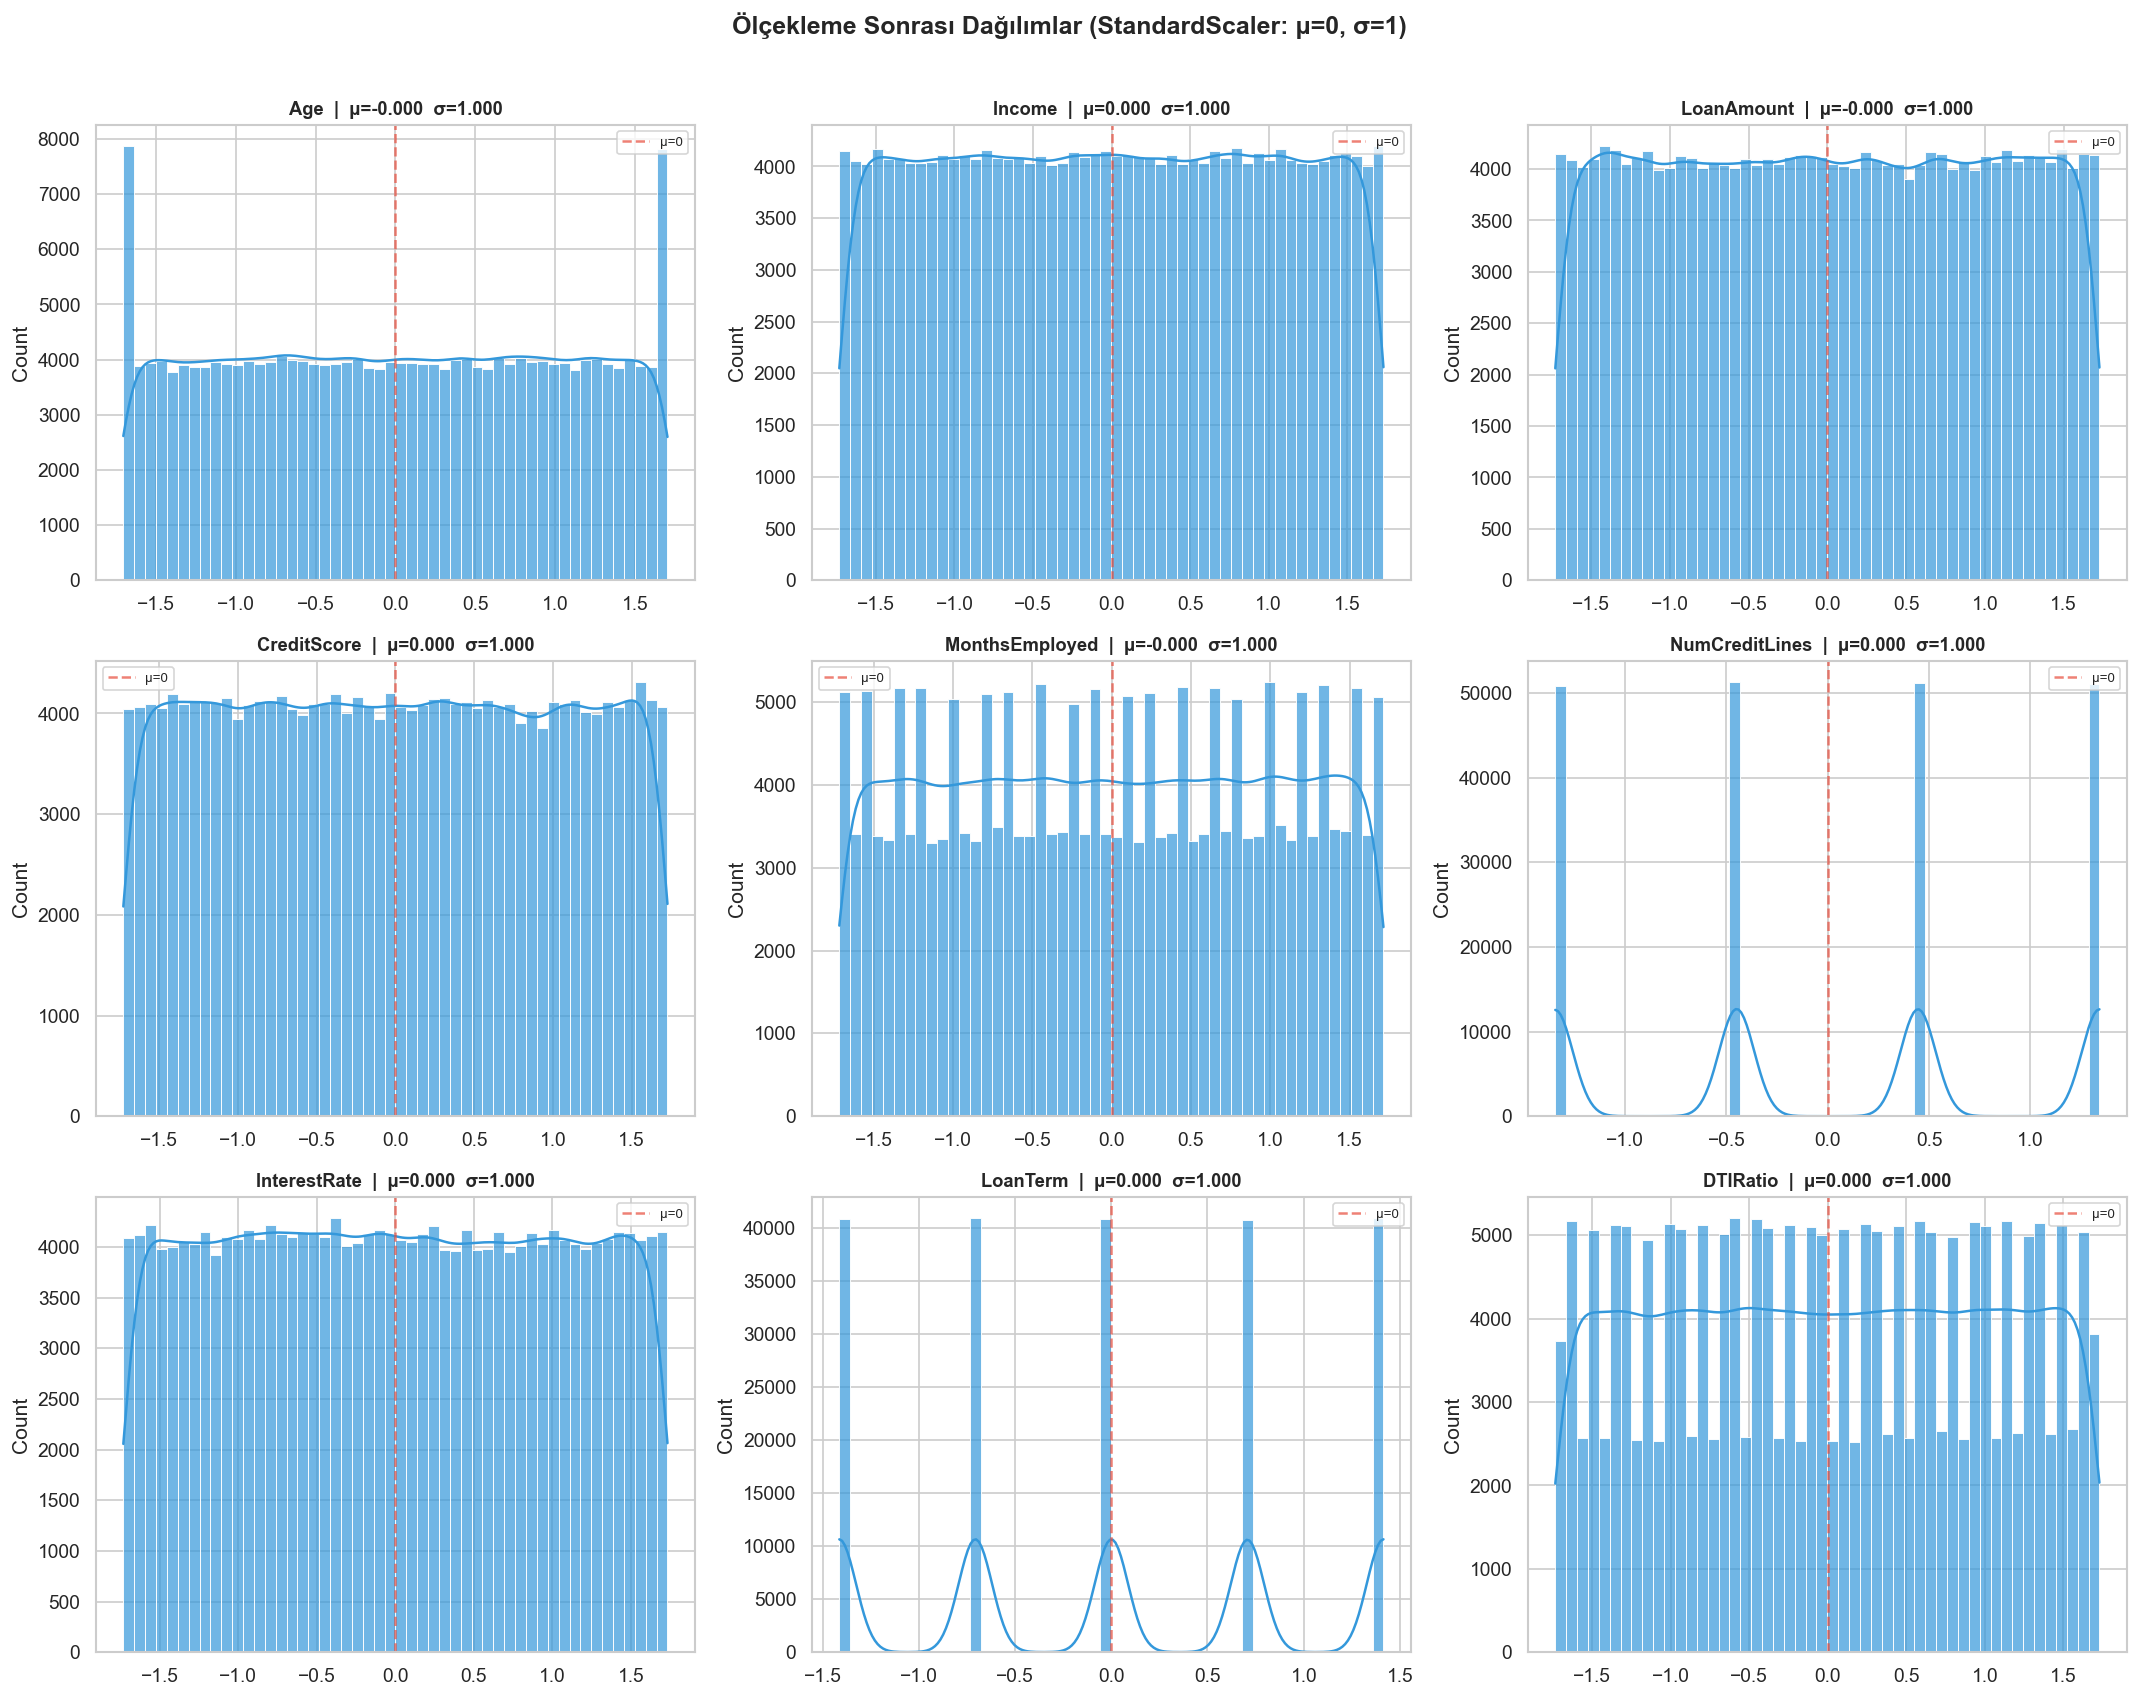

In [11]:
# ---------------------------------------------------------------------------
# Ölçekleme sonrası dağılım görselleştirmesi
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    ax = axes[i]
    sns.histplot(X_train[col], bins=50, kde=True, ax=ax, color="#3498db", alpha=0.7)
    ax.axvline(0, color="#e74c3c", linestyle="--", linewidth=1.5, alpha=0.7, label="μ=0")
    ax.set_title(f"{col}  |  μ={X_train[col].mean():.3f}  σ={X_train[col].std():.3f}", fontsize=11)
    ax.set_xlabel("")
    ax.legend(fontsize=8)

fig.suptitle(
    "Ölçekleme Sonrası Dağılımlar (StandardScaler: μ=0, σ=1)",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}10_scaled_distributions.png", bbox_inches="tight")
plt.show()

---
## 8. İşlenmiş Veriyi Kaydetme

Temizlenmiş ve dönüştürülmüş veri `data/processed/` klasörüne kaydedilir.  
Scaler ve Encoder nesneleri de `models/` klasörüne kaydedilir.

**Kaydedilen dosyalar:**

| Dosya | İçerik | Kullanım Yeri |
|-------|--------|---------------|
| `X_train.csv` | Eğitim feature'ları | Notebook 03 — Model eğitimi |
| `X_test.csv` | Test feature'ları | Notebook 03 — Model değerlendirme |
| `y_train.csv` | Eğitim hedef değişkeni | Notebook 03 — Model eğitimi |
| `y_test.csv` | Test hedef değişkeni | Notebook 03 — Model değerlendirme |
| `scaler.joblib` | StandardScaler nesnesi | API — Yeni veri dönüştürme |
| `label_encoders.joblib` | LabelEncoder nesneleri | API — Yeni veri dönüştürme |

In [12]:
# ---------------------------------------------------------------------------
# İşlenmiş veriyi CSV olarak kaydet
# ---------------------------------------------------------------------------
X_train.to_csv(f"{PROCESSED_DIR}X_train.csv", index=False)
X_test.to_csv(f"{PROCESSED_DIR}X_test.csv", index=False)
y_train.to_csv(f"{PROCESSED_DIR}y_train.csv", index=False)
y_test.to_csv(f"{PROCESSED_DIR}y_test.csv", index=False)

print("✅ İşlenmiş veriler kaydedildi:")
for fname in ["X_train.csv", "X_test.csv", "y_train.csv", "y_test.csv"]:
    fpath = f"{PROCESSED_DIR}{fname}"
    size_kb = os.path.getsize(fpath) / 1024
    print(f"   📄 {fname:<16} → {size_kb:>8.1f} KB")

✅ İşlenmiş veriler kaydedildi:
   📄 X_train.csv      →  38228.1 KB
   📄 X_test.csv       →   9557.6 KB
   📄 y_train.csv      →    598.5 KB
   📄 y_test.csv       →    149.6 KB


In [13]:
# ---------------------------------------------------------------------------
# Scaler ve Encoder nesnelerini kaydet (inference pipeline için)
# ---------------------------------------------------------------------------
joblib.dump(scaler, f"{MODELS_DIR}scaler.joblib")
joblib.dump(label_encoders, f"{MODELS_DIR}label_encoders.joblib")

print("✅ Pipeline nesneleri kaydedildi:")
print(f"   📦 scaler.joblib          → {MODELS_DIR}")
print(f"   📦 label_encoders.joblib  → {MODELS_DIR}")
print("\n💡 Bu nesneler API'de yeni müşteri verisi geldiğinde aynı dönüşümü uygulamak için kullanılacak.")

✅ Pipeline nesneleri kaydedildi:
   📦 scaler.joblib          → ../models/
   📦 label_encoders.joblib  → ../models/

💡 Bu nesneler API'de yeni müşteri verisi geldiğinde aynı dönüşümü uygulamak için kullanılacak.


---
## 9. Doğrulama & Son Kontrol

Kaydedilen verileri yeniden yükleyerek her şeyin doğru kaydedildiğini kontrol ediyoruz.

In [14]:
# ---------------------------------------------------------------------------
# Doğrulama: Kaydedilen veriyi yeniden yükle ve kontrol et
# ---------------------------------------------------------------------------
X_train_check = pd.read_csv(f"{PROCESSED_DIR}X_train.csv")
X_test_check = pd.read_csv(f"{PROCESSED_DIR}X_test.csv")
y_train_check = pd.read_csv(f"{PROCESSED_DIR}y_train.csv").squeeze()
y_test_check = pd.read_csv(f"{PROCESSED_DIR}y_test.csv").squeeze()

print("🔍 Doğrulama Sonuçları:")
print(f"   X_train boyut : {X_train_check.shape} → {'✅' if X_train_check.shape == X_train.shape else '❌'}")
print(f"   X_test boyut  : {X_test_check.shape} → {'✅' if X_test_check.shape == X_test.shape else '❌'}")
print(f"   y_train boyut : {y_train_check.shape[0]:,} → {'✅' if len(y_train_check) == len(y_train) else '❌'}")
print(f"   y_test boyut  : {y_test_check.shape[0]:,} → {'✅' if len(y_test_check) == len(y_test) else '❌'}")
print(f"   Eksik değer   : {X_train_check.isnull().sum().sum() + X_test_check.isnull().sum().sum()} → {'✅' if X_train_check.isnull().sum().sum() == 0 else '❌'}")
print(f"   String sütun  : {X_train_check.select_dtypes('object').shape[1]} → {'✅' if X_train_check.select_dtypes('object').shape[1] == 0 else '❌'}")

# Scaler doğrulama
scaler_check = joblib.load(f"{MODELS_DIR}scaler.joblib")
le_check = joblib.load(f"{MODELS_DIR}label_encoders.joblib")
print(f"   Scaler yükleme: {'✅' if scaler_check is not None else '❌'}")
print(f"   Encoder yükleme: {'✅' if len(le_check) == len(CATEGORICAL_COLS) else '❌'}")

🔍 Doğrulama Sonuçları:
   X_train boyut : (204277, 16) → ✅
   X_test boyut  : (51070, 16) → ✅
   y_train boyut : 204,277 → ✅
   y_test boyut  : 51,070 → ✅
   Eksik değer   : 0 → ✅
   String sütun  : 0 → ✅
   Scaler yükleme: ✅
   Encoder yükleme: ✅


In [15]:
# ---------------------------------------------------------------------------
# Son özet tablosu
# ---------------------------------------------------------------------------
print("=" * 65)
print("               🔧 ÖN-İŞLEME ÖZETİ                ")
print("=" * 65)
print(f"  Ham veri          : 255,347 × 18")
print(f"  ID sütunu         : Kaldırıldı (LoanID)")
print(f"  Aykırı değerler   : IQR × {OUTLIER_THRESH} ile kırpıldı")
print(f"  Kategorik encoding: LabelEncoder ({len(CATEGORICAL_COLS)} sütun)")
print(f"  Ölçekleme         : StandardScaler (μ=0, σ=1)")
print(f"  Train seti        : {X_train.shape[0]:,} satır × {X_train.shape[1]} özellik")
print(f"  Test seti         : {X_test.shape[0]:,} satır × {X_test.shape[1]} özellik")
print(f"  Sınıf dengesi     : {(y_train == 0).sum():,} / {(y_train == 1).sum():,} (train)")
print(f"  scale_pos_weight  : ~{(y_train == 0).sum() / (y_train == 1).sum():.1f} (modelde kullanılacak)")
print("=" * 65)
print("\n📂 Kaydedilen dosyalar:")
print(f"   data/processed/  → X_train.csv, X_test.csv, y_train.csv, y_test.csv")
print(f"   models/          → scaler.joblib, label_encoders.joblib")
print(f"   reports/figures/ → 09_outlier_clipping_comparison.png, 10_scaled_distributions.png")
print("\n🚀 Sonraki adım: 03_modeling.ipynb → XGBoost eğitimi + SHAP açıklamaları")

               🔧 ÖN-İŞLEME ÖZETİ                
  Ham veri          : 255,347 × 18
  ID sütunu         : Kaldırıldı (LoanID)
  Aykırı değerler   : IQR × 1.5 ile kırpıldı
  Kategorik encoding: LabelEncoder (7 sütun)
  Ölçekleme         : StandardScaler (μ=0, σ=1)
  Train seti        : 204,277 satır × 16 özellik
  Test seti         : 51,070 satır × 16 özellik
  Sınıf dengesi     : 180,555 / 23,722 (train)
  scale_pos_weight  : ~7.6 (modelde kullanılacak)

📂 Kaydedilen dosyalar:
   data/processed/  → X_train.csv, X_test.csv, y_train.csv, y_test.csv
   models/          → scaler.joblib, label_encoders.joblib
   reports/figures/ → 09_outlier_clipping_comparison.png, 10_scaled_distributions.png

🚀 Sonraki adım: 03_modeling.ipynb → XGBoost eğitimi + SHAP açıklamaları


---
## 📋 Özet & Sonraki Adımlar

### Yapılan İşlemler
| # | İşlem | Detay |
|---|-------|-------|
| 1 | ID kaldırma | `LoanID` sütunu düşürüldü |
| 2 | Outlier kırpma | IQR × 1.5 ile alt/üst sınıra çekildi |
| 3 | Encoding | 7 kategorik sütun → LabelEncoder |
| 4 | Train/Test split | %80/%20 — Stratified (sınıf oranı korundu) |
| 5 | Scaling | 9 sayısal sütun → StandardScaler (μ=0, σ=1) |
| 6 | Kaydetme | CSV + joblib dosyaları oluşturuldu |

### Sınıf Dengesizliği Notu
- SMOTE burada **uygulanmadı** — doğru yaklaşım modelleme aşamasında uygulamaktır
- Bunun yerine XGBoost'un `scale_pos_weight` parametresi kullanılacak (config'de ~7.6 olarak ayarlı)

### Sonraki Notebook (`03_modeling.ipynb`):
1. İşlenmiş veriyi yükle
2. XGBoost modeli eğit (`scale_pos_weight=7.6`)
3. Hiperparametre optimizasyonu
4. Model değerlendirme (Classification Report, ROC-AUC, Confusion Matrix)
5. SHAP açıklanabilirlik analizi
6. Modeli kaydet (`models/xgboost_model.joblib`)

---
*Ön-işleme tamamlandı. Veriler `data/processed/` klasörüne, pipeline nesneleri `models/` klasörüne kaydedilmiştir.*